In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vishv\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vishv\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [18]:
train = pd.read_csv('train_data.txt', sep=':::',
                    names=['ID','TITLE','GENRE','DESCRIPTION'],
                    engine='python')

test = pd.read_csv('test_data.txt', sep=':::',
                   names=['ID','TITLE','DESCRIPTION'],
                   engine='python')

print(train.shape, test.shape)
train.head()

(54214, 4) (54200, 3)


,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


Null values:
 ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64

Genre counts:
 GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64


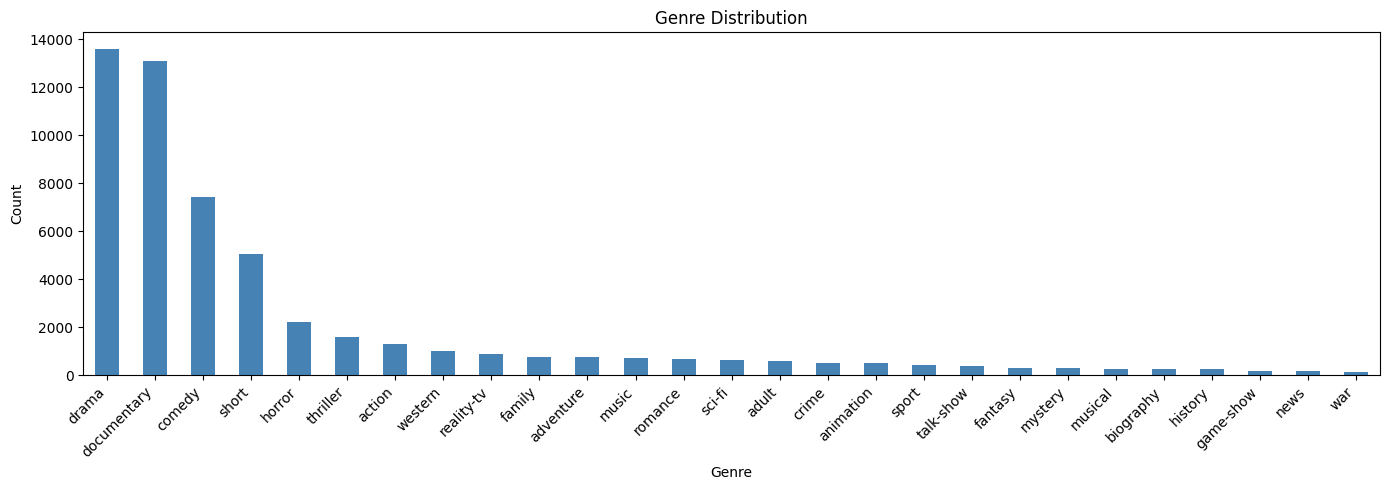

In [19]:
train['GENRE'] = train['GENRE'].str.strip()

print("Null values:\n", train.isnull().sum())
print("\nGenre counts:\n", train['GENRE'].value_counts())

plt.figure(figsize=(14,5))
train['GENRE'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()

In [20]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

train['clean_plot'] = train['DESCRIPTION'].apply(clean_text)

# verify cleaning worked
print(train['DESCRIPTION'].iloc[0][:150])
print(train['clean_plot'].iloc[0][:150])

 Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few we
listen convers doctor parent yearold oscar learn nobodi courag tell week live furiou refus speak anyon except straighttalk rose ladi pink meet hospit 


Training samples : 43371
Testing samples  : 10843

TF-IDF matrix shape (train) : (43371, 10000)
TF-IDF matrix shape (test)  : (10843, 10000)

✅ Split and vectorization done!


In [21]:
X = train['clean_plot']
y = train['GENRE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(43371, 10000) (10843, 10000)


In [22]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)
nb_acc  = accuracy_score(y_test, nb_pred)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)

svm = LinearSVC(max_iter=1000, random_state=42)
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
svm_acc  = accuracy_score(y_test, svm_pred)

print(f"Naive Bayes        : {nb_acc:.4f}")
print(f"Logistic Regression: {lr_acc:.4f}")
print(f"LinearSVC          : {svm_acc:.4f}")

Naive Bayes        : 0.4996
Logistic Regression: 0.5838
LinearSVC          : 0.5699


              precision    recall  f1-score   support

      action       0.51      0.28      0.36       263
       adult       0.79      0.29      0.42       118
   adventure       0.57      0.15      0.24       155
   animation       0.50      0.09      0.15       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.60      0.56      1490
       crime       0.33      0.04      0.07       101
 documentary       0.67      0.85      0.75      2619
       drama       0.54      0.77      0.64      2723
      family       0.50      0.08      0.13       157
     fantasy       1.00      0.02      0.03        65
   game-show       0.90      0.46      0.61        39
     history       0.00      0.00      0.00        49
      horror       0.65      0.58      0.62       441
       music       0.64      0.40      0.49       146
     musical       1.00      0.02      0.04        55
     mystery       0.00      0.00      0.00        64
        news       1.00    

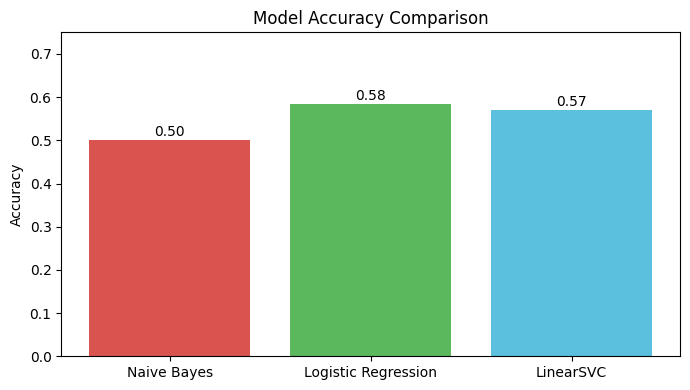

In [23]:
print(classification_report(y_test, lr_pred))

models = ['Naive Bayes', 'Logistic Regression', 'LinearSVC']
scores = [nb_acc, lr_acc, svm_acc]

plt.figure(figsize=(7,4))
plt.bar(models, scores, color=['#d9534f','#5cb85c','#5bc0de'])
plt.ylim(0, 0.75)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

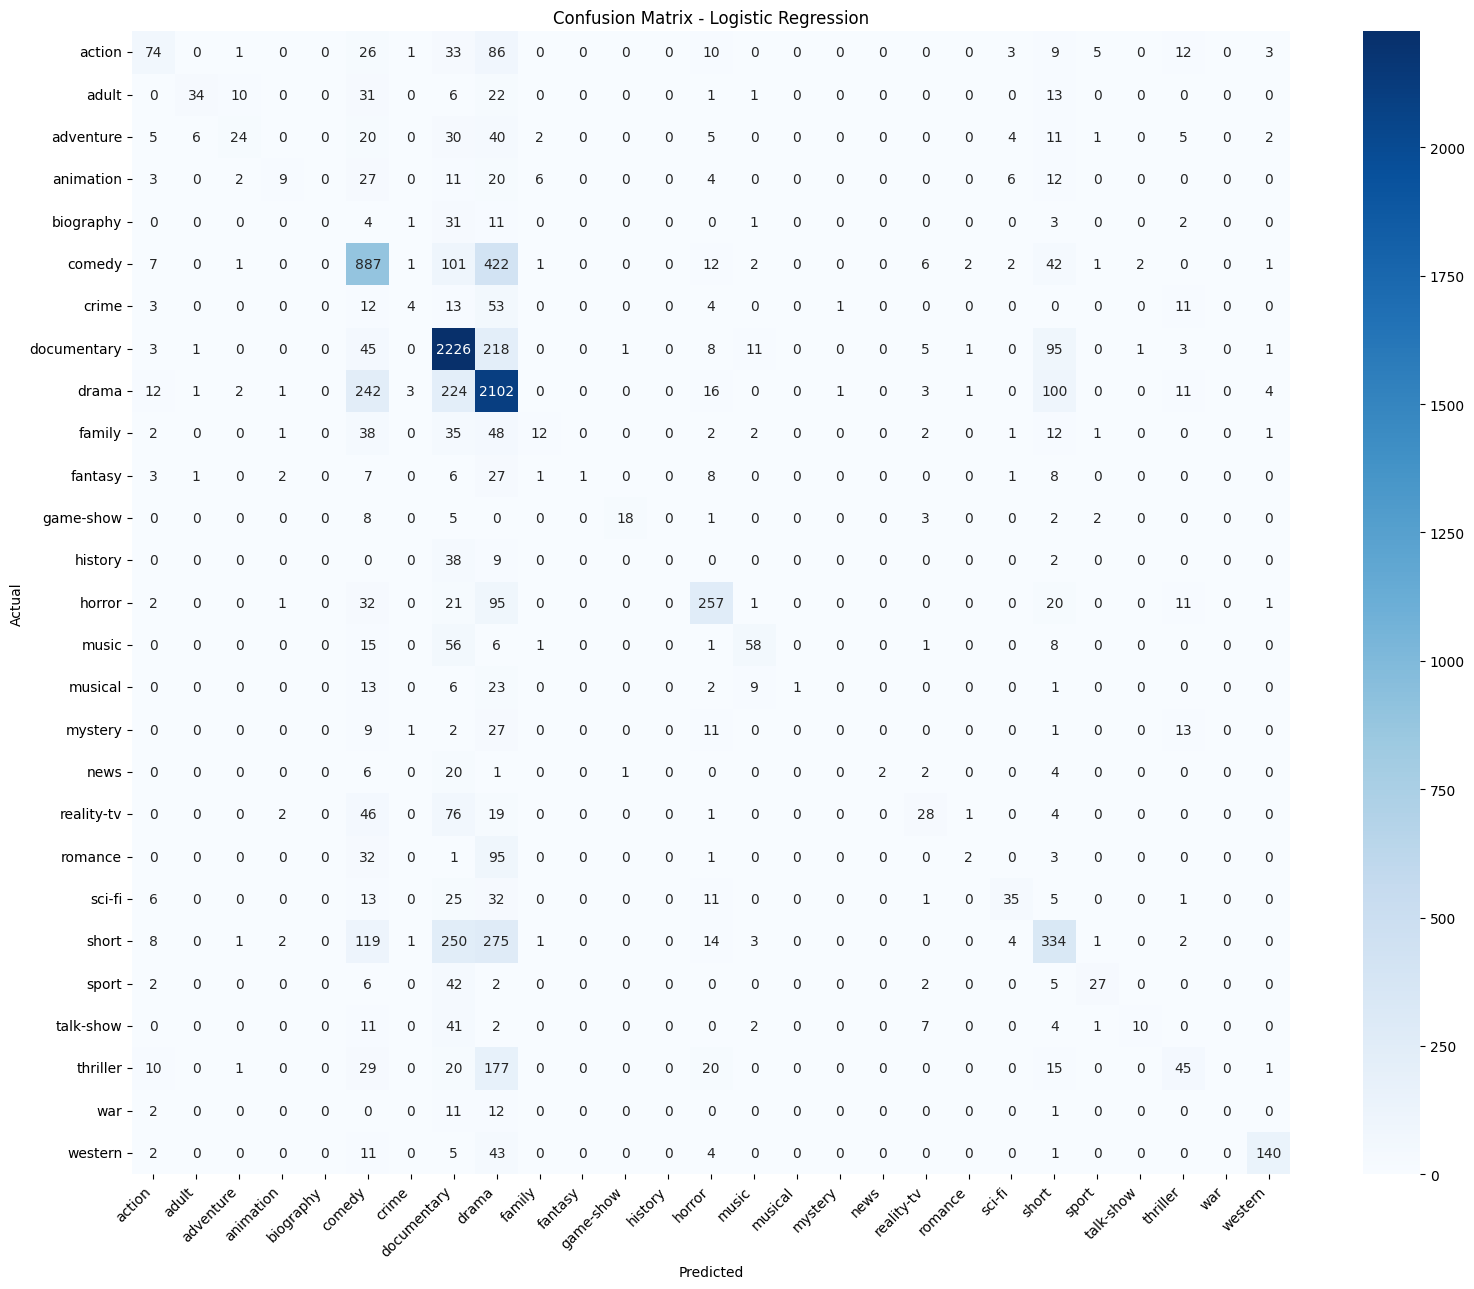

In [24]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, lr_pred, labels=labels)

plt.figure(figsize=(16,13))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels,
            cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

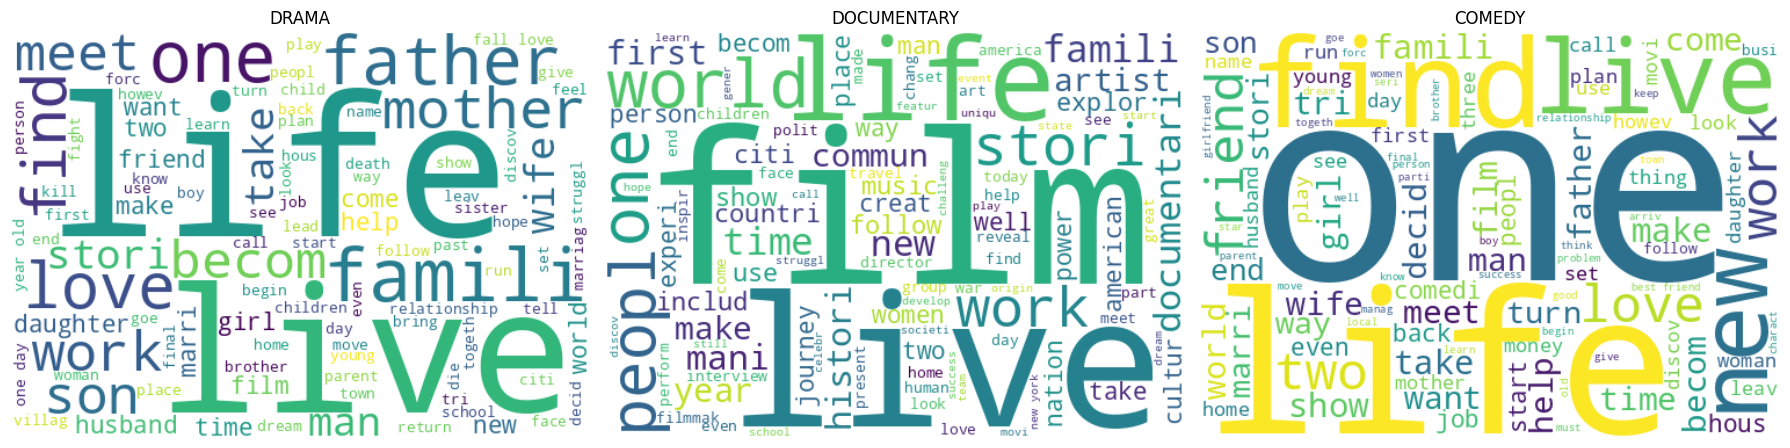

In [25]:
top_genres = ['drama', 'documentary', 'comedy']
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, genre in zip(axes, top_genres):
    text = ' '.join(train[train['GENRE'] == genre]['clean_plot'].values)
    wc = WordCloud(width=500, height=350,
                   background_color='white',
                   max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(genre.upper())

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

In [27]:
def predict_genre(plot):
    cleaned    = clean_text(plot)
    vectorized = tfidf.transform([cleaned])
    print("Naive Bayes        :", nb.predict(vectorized)[0])
    print("Logistic Regression:", lr.predict(vectorized)[0])
    print("LinearSVC          :", svm.predict(vectorized)[0])

predict_genre("A soldier uncovers a government conspiracy and fights "
              "to expose the truth before time runs out.")

predict_genre("Strange noises fill the house every night. The family "
              "starts seeing a dark figure in every mirror.")

Naive Bayes        : documentary
Logistic Regression: action
LinearSVC          : action
Naive Bayes        : drama
Logistic Regression: horror
LinearSVC          : horror
